# 🐍 Python Level 2 - Intermediate course
## Class 4 Mini-Project — Expenses Review Toolkit
### 📝 Mini-Project

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">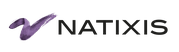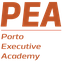</div>

---

---

## What you will build

In the Level 1 project you produced a budget review. It worked, and it was one long cell.

Today you build the same kind of review as a **toolkit**: a handful of small functions, each
doing one job, and a final cell that just calls them in order. Then you add the charts. By the
end you will have something you could re-run next month on a new file by changing one line which is the difference between a script and a tool.

```
   expenses.csv
        │
        ▼
   clean_expenses()           part 2   one function
        │
        ▼
   variance_pct()             part 3   the rules
   classify_variance()
        │
        ▼
   summarise_by_department()  part 4   comprehensions
        │
        ▼
   print_report()             part 5   the table
        │
        ▼
   draw_dashboard()           part 6   four charts + a PNG
        │
        ▼
   run_review()               part 7   calls them all
```

> 🕐 You have the full session. The parts are in order and **each one leaves you with something
> that runs** if you only reach part 5 you still have a working report.

---

---
## The data

The same `expenses.csv` you have used since Level 1. Put it in your Google Drive before you
start.

| Column | Holds |
|--------|-------|
| `department` | which department spent the money |
| `category` | Travel, Software, Training, Office or Consulting |
| `month` | `2026-01` … `2026-06` |
| `budget` | what was planned, in EUR |
| `actual` | what was actually spent, in EUR |
| `notes` | always empty — drop it |

It still has duplicated rows, blank `actual` values, and departments written in more than one
way. Part 2 deals with all of it and this time inside a function.

---

---
## Requirements

Your finished notebook must use all of these.

| # | Requirement | From class |
|---|-------------|-----------|
| 1 | Load and inspect a CSV with pandas | L1C3 |
| 2 | A **function** that takes a DataFrame and returns a cleaned one | L2C1 |
| 3 | Small functions with **one job each**, and a **docstring** on every one | L2C1 |
| 4 | **Default arguments**, so the rules can be changed without editing the function | L2C1 |
| 5 | Test a function on values you can check **by hand** before trusting it | L2C1 |
| 6 | A **list comprehension** that builds a list of dicts | L2C2 |
| 7 | **`sorted` with a `lambda` key** | L2C2 |
| 8 | A **set comprehension**, and **`any`** / **`all`** | L2C2 |
| 9 | A function that only **prints**, kept separate from the ones that calculate | L2C1 |
| 10 | A **2x2 dashboard** with four chart types, saved as a PNG | L2C3 |
| 11 | A final function that **calls the others** in order | L2C1 |

---

## ⚙️ Setup

Run this first.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "expenses.csv" # Don't forget to upload the file expenses.csv
sns.set_style("whitegrid")

---
## Part 1 — Load the file

Read the CSV into `expenses` and print its shape, its column names as a list, and how many
different departments it *thinks* it has.

Expected output:
```
Rows and columns : (154, 6)
Columns          : ['department', 'category', 'month', 'budget', 'actual', 'notes']
Departments (raw): 12
```

In [ ]:
# Part 1

---
## Part 2 — A cleaning function

Write `clean_expenses(df)` with a docstring. It must **take** a DataFrame and **return** a
cleaned copy: duplicates dropped, `department` lower-cased, `notes` dropped, and rows with no
`actual` removed.

Call it, then print the shape before and after, and the sorted departments.

Expected output:
```
Before: (154, 6)
After : (141, 5)
Departments: ['finance', 'hr', 'it', 'marketing', 'operations']
```

> 💡 Start with `clean = df.drop_duplicates().copy()` and build from there. Because the function
> works on a copy, the original `expenses` is untouched which is why you can print both shapes.

In [ ]:
# Part 2

---
## Part 3 — Two rule functions, tested on their own

Write two small functions, each with a docstring:

1. `variance_pct(budget, actual)` — returns `actual` as a percentage of `budget`, to 1 decimal
2. `classify_variance(used_pct, over_limit=110, under_limit=90)` — returns `"OVER"` above the
   over limit, `"under"` below the under limit, and `"on budget"` in between

Then **test them on numbers you can check in your head**, before letting them near 141 rows:
`variance_pct(1000, 1150)`, `variance_pct(1000, 880)`, then `classify_variance` on `115.0`,
`95.0` and `88.0` — and once more on `95.0` with `over_limit=94`, to prove the default can be
overridden.

Expected output:
```
115.0
88.0
OVER
on budget
under
OVER
```

> 💡 Wrap the division in `float()` — `round(float(actual) / float(budget) * 100, 1)`. Without
> it, a pandas total comes back as `np.float64(114.7)` later on, which is the right number
> wearing a hat.
>
> 💡 That last call is the point of default arguments: the rule changed without the function
> being edited.

In [ ]:
# Part 3

---
## Part 4 — The summary, built with comprehensions

Write a function `summarise_by_department(df)` that returns a **list of dicts**, one per department,
sorted by `used_pct` from **highest to lowest**.

**Inside the function:**
1. Use two `groupby` results — one totalling `budget`, one totalling `actual`
2. Build the list with **one comprehension** over `budgets.index`
3. Each dict has the keys `group`, `budget`, `actual` and `used_pct`
4. Sort with `sorted(..., key=lambda row: ..., reverse=True)`

**Outside the function:**

5. Call `summarise_by_department()` on your cleaned DataFrame from Part 2 and store the
   result in a variable.

6. Print each row from step 5 on its own line.

7. Print three more lines from step 5:
  - A **set comprehension** with the departments whose `used_pct` is above 100, printed **sorted**
  - Whether **any** department is over 110%
  - Whether **all** departments are over 80%.

Five rows are expected. Each row must look like this, highest `used_pct` first:
```
{'group': 'operations', 'budget': 564500, 'actual': 647661.96, 'used_pct': 114.7}
```

> 💡 Name the key `group`, not `department`. In stretch goal 1 you run the same review by
> **category**, and a key named for one case would lock you to it.
>
> 💡 Use `int(budgets[department])` and `round(float(actuals[department]), 2)` to show plain numbers
> instead of numpy types.
>
> 💡 Get `used_pct` by calling your `variance_pct()` from Part 3. Don't rewrite the
> percentage calculation.
>
> 💡 For the last two lines, Python has two built-ins whose names are almost the questions
> themselves. Each one fits on a single line with a generator expression.

In [ ]:
# Part 4

---
## Part 5 — A reporting function

Write `print_report(rows, label="department")` since it **only prints** and returns nothing. Keep
it separate from the functions that work the numbers out.

It must print a heading, the column titles, one line per row with its status from
`classify_variance()`, then a count of how many rows fell into each status.

Use this layout:
```
EXPENSES REVIEW
----------------------------------------------------------
department        budget      actual    used   status
----------------------------------------------------------
operations       564,500  647,661.96  114.7%   OVER
...
----------------------------------------------------------
OVER              ?
on budget         ?
under             ?
```

> 💡 The line is `f"{row['group']:<12}{row['budget']:>12,}{row['actual']:>12,.2f}"` followed by
> `f"{row['used_pct']:>7.1f}%   {status}"`. The separator is `"-" * 58`.
>
> 💡 The column titles can use the same widths as the rows, so they line up automatically.
> An f-string can format plain text too, not just variables: `f"{label:<12}{'budget':>12}..."`
> puts `department` on the left and `budget` on the right of a 12-character slot.
>
> 💡 Count the statuses with a dict you start at zero — `counts = {"OVER": 0, ...}` — then
> `counts[status] += 1`. That is the L1C2 pattern again.
>
> 💡 `label` is a parameter so the heading is right when stretch goal 1 groups by category.

In [ ]:
# Part 5

---
## Part 6 — A dashboard function

Write `draw_dashboard(df, rows, filename)` that draws **one figure with four charts** in a 2x2
grid on an 11 by 7 canvas, saves it, and shows it.

| Position | Chart |
|----------|-------|
| top left | actual spend by month — a **line** |
| top right | `used_pct` per department — a **bar**, with a dashed line at **100** |
| bottom left | the spread of `actual` — a **histogram**, 12 bins |
| bottom right | `budget` against `actual` — a **scatter**, with a diagonal reference line |

Your figure must show:
- Four charts, none overlapping, each with a title and labelled axes
- The month labels rotated so they fit
- The top-right chart with **one bar above the 100 line** and one clearly below that is the
  finding, visible in a second
- The scatter's points forming a rising band along the diagonal

> 💡 Get the department names and percentages out of `rows` with two comprehensions.
>
> 💡 `plt.axhline(y=100, ...)` for the horizontal line; `plt.plot([0, 40000], [0, 40000], ...)`
> for the diagonal.
>
> 💡 `plt.savefig(filename, dpi=150)` must come **before** `plt.show()`, or you save a blank
> image.

In [ ]:
# Part 6

---
## Part 7 — The whole thing, as a list of calls

Write `run_review(csv_path, chart_name="expenses_review.png")` that does the entire job by
**calling the functions you already have**: load, clean, summarise, report, chart. It should
`return` the summary rows.

Then call it once, and print the worst department and its percentage from what it returned.

Your function body should be about six lines and need **no comments** if it does, the
function names are not saying enough.

> 💡 This is the part to compare with the Level 1 project. The work is the same; the shape is
> completely different.

In [ ]:
# Part 7

---
## 🌟 Stretch goals

Only if you finish early.

1. **The same review, by category.** Write `summarise_by(df, column)` — the same function, but
   with the grouping column as a parameter. Then call
   `print_report(summarise_by(clean, "category"), label="category")`. If parts 4 and 5 were
   written well, this needs no other changes. *(That is the test of a good function.)*
2. **Tighter limits.** Loop the summary and call `classify_variance()` with
   `over_limit=100, under_limit=97`. How many departments change verdict? Note that you did not
   have to edit `classify_variance` to find out.
3. **Save the report as well as the chart.** Turn the summary rows into a DataFrame with
   `pd.DataFrame(rows)` and export it with `.to_csv(..., index=False)`.

In [ ]:
# Stretch goals

---
## 💡 If you get stuck

**"My shapes do not match."** Everything downstream depends on part 2. If `clean.shape` is not
`(141, 5)`, fix that before going on.

**"`np.float64(114.7)` in my output."** The right number, wearing a hat. `float()` inside
`variance_pct()` is the fix.

**"`KeyError: 'department'`."** You named the dict key `group` in part 4 but asked for
`department` in part 5, or the other way round. Pick one and be consistent.

**"My comprehension will not work."** Write it as a normal `for` loop with `.append()` first,
get the right answer, then collapse it. That is what everyone does.

**"The chart is blank when I open the PNG."** `savefig()` came after `show()`. Swap them.

**"I cannot see where to start part 7."** Write the five function calls as comments first, then
replace each comment with its line.

Ask early rather than late.